In [18]:
'''after experimenting with layers, optimizers, analysing the data, analyzing class imbalance,
    different activation functions, hyperparameter tuning(using different hyperparameters)
    this is the final model that i have created, keeping the "sgd" optimizer required in the assignment question'''

'after experimenting with layers, optimizers, analysing the data, analyzing class imbalance,\n    different activation functions, hyperparameter tuning(using different hyperparameters)\n    this is the final model that i have created, keeping the "sgd" optimizer required in the assignment question'

In [2]:
!pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 920.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 106.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, x_test.shape)

x_train = x_train/255.0
x_test = x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


In [4]:
x_train = x_train.reshape(x_train.shape[0], -1) # Reshape to 2D
x_test = x_test.reshape(x_test.shape[0], -1) # Reshape to 2D

x_train = pd.DataFrame(x_train)
x_test = pd.DataFrame(x_test)

print(x_test.head(1))

   0    1    2    3    4    5    6    7    8    9    ...  774  775  776  777  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

   778  779  780  781  782  783  
0  0.0  0.0  0.0  0.0  0.0  0.0  

[1 rows x 784 columns]


In [5]:
x_train.shape

(60000, 784)

In [6]:
x_train.isna().sum().sum()

np.int64(0)

In [7]:
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)


In [8]:
y_train.nunique()

,0
0,10


In [9]:
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape = (x_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer = 'sgd',  # Stochastic Gradient Descent
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(x_train, y_train,
                    batch_size = 128,
                    epochs = 32,
                    validation_split = 0.15
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6330 - loss: 1.3931 - val_accuracy: 0.8611 - val_loss: 0.5725
Epoch 2/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8735 - loss: 0.4769 - val_accuracy: 0.9026 - val_loss: 0.3523
Epoch 3/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8997 - loss: 0.3574 - val_accuracy: 0.9164 - val_loss: 0.2942
Epoch 4/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9124 - loss: 0.3092 - val_accuracy: 0.9259 - val_loss: 0.2617
Epoch 5/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9206 - loss: 0.2785 - val_accuracy: 0.9301 - val_loss: 0.2413
Epoch 6/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9276 - loss: 0.2559 - val_accuracy: 0.9361 - val_loss: 0.2243
Epoch 7/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9323 - loss: 0.2377 - val_accuracy: 0.9426 - val_loss: 0.2063
Epoch 8/32
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9375 - loss: 0.2220 - val_accuracy: 0.

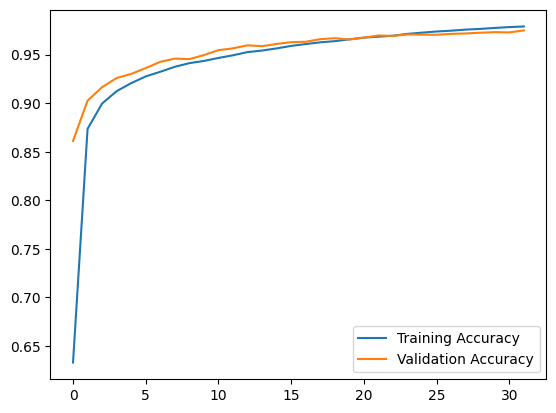

In [11]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend()

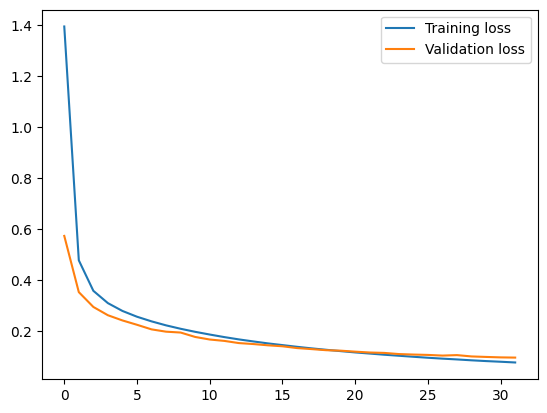

In [12]:
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()

In [13]:
# the model training accuracy is 97.8%, but validation accuracy is also 97.1%, so it is not overfitting, it is very good
# it is 99% and 98%(val) accuracy with adam optimizer

In [14]:
predictions = model.predict(x_test)
predictions[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step


array([5.24259258e-06, 4.11972252e-07, 1.62060140e-04, 3.08169983e-03,
       1.03226114e-07, 4.95941822e-06, 9.33519706e-10, 9.96711254e-01,
       1.63676577e-06, 3.27464622e-05], dtype=float32)

In [15]:
predictions.shape

(10000, 10)

In [16]:
accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(predictions, axis=1))
print("Test Accuracy : ", accuracy)

Test Accuracy :  0.9711


Total misclassified images: 289


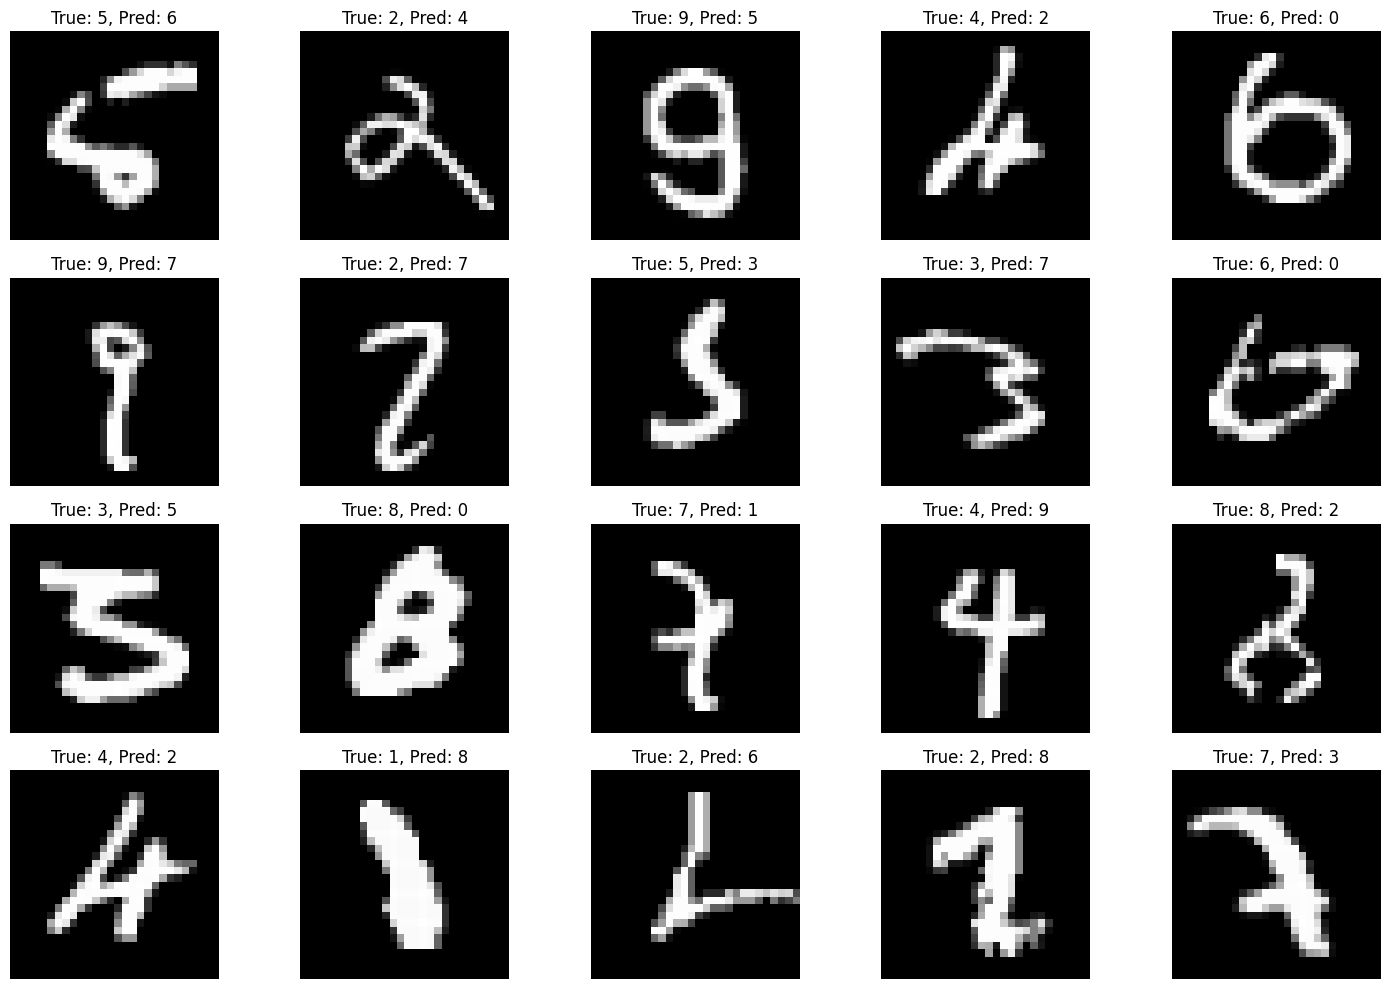

In [19]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

misclassified_indices = np.where(predicted_labels != true_labels)[0]

print(f"Total misclassified images: {len(misclassified_indices)}")

# Reshape x_test back to original image dimensions for plotting
x_test_images = x_test.values.reshape(-1, 28, 28)

# Display up to 20 misclassified images
num_display = min(20, len(misclassified_indices))
plt.figure(figsize=(15, 10))
for i, bad_index in enumerate(misclassified_indices[:num_display]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test_images[bad_index], cmap='gray')
    plt.title(f"True: {true_labels[bad_index]}, Pred: {predicted_labels[bad_index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()